In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [15]:
spend_df=pd.read_csv("D:/portfolio projects/spend_analysis_dataset.csv")
spend_df.head()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
0,TXN001,Desk Chair,Furniture,10,113.15,1131.50,2024-04-19,TechMart Inc.,Kelly Joseph
1,TXN002,Stapler,Office Supplies,16,12.62,201.92,2024-07-06,CloudSoft Corp.,Kelly Joseph
2,TXN003,Annual Software License,Software,1,5649.34,5649.34,2024-09-10,TechMart Inc.,Kelly Joseph
3,TXN004,Notepad,Stationery,13,2.92,37.96,2024-01-21,FurniWorks Ltd.,Luis Holland
4,TXN005,Notepad,Stationery,19,1.39,26.41,2024-02-03,TechMart Inc.,Cynthia Jenkins


In [16]:
spend_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  500 non-null    object 
 1   ItemName       500 non-null    object 
 2   Category       500 non-null    object 
 3   Quantity       500 non-null    int64  
 4   UnitPrice      500 non-null    float64
 5   TotalCost      500 non-null    float64
 6   PurchaseDate   500 non-null    object 
 7   Supplier       500 non-null    object 
 8   Buyer          500 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.3+ KB


In [17]:
spend_df.describe()

,Quantity,UnitPrice,TotalCost
count,500.000000,500.000000,500.00000
mean,9.640000,854.245100,2481.16106
std,6.168834,2132.890832,3527.35316
min,1.000000,1.060000,1.56000
25%,4.000000,14.380000,145.92750
50%,10.000000,143.595000,918.56000
75%,15.000000,287.925000,3123.56750
max,20.000000,9909.240000,18494.60000


In [18]:
spend_df.columns = spend_df.columns.str.replace('([a-z])([A-Z])', r'\1_\2', regex=True).str.lower()
spend_df.columns

Index(['transaction_id', 'item_name', 'category', 'quantity', 'unit_price',
       'total_cost', 'purchase_date', 'supplier', 'buyer'],
      dtype='object')

In [19]:
spend_df.isnull().sum()   

transaction_id    0
item_name         0
category          0
quantity          0
unit_price        0
total_cost        0
purchase_date     0
supplier          0
buyer             0
dtype: int64

In [20]:
spend_df.duplicated().sum()

np.int64(0)

In [25]:
spend_df["purchase_date"] = pd.to_datetime(spend_df["purchase_date"])


In [26]:
spend_df["spend_bucket"] = pd.cut(
    spend_df["total_cost"],
    bins=[0, 500, 2000, spend_df["total_cost"].max()],
    labels=["Low Spend", "Medium Spend", "High Spend"]
)


In [27]:
spend_df["total_cost"].sum()


np.float64(1240580.5299999998)

In [28]:
spend_df["total_cost"].mean()


np.float64(2481.1610599999995)

In [29]:
spend_df["transaction_id"].nunique()


500

In [30]:
category_spend = (
    spend_df.groupby("category")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

category_spend


category
Electronics        697805.23
Software           336018.00
Furniture          172818.61
Accessories         20857.24
Stationery           6753.18
Office Supplies      6328.27
Name: total_cost, dtype: float64

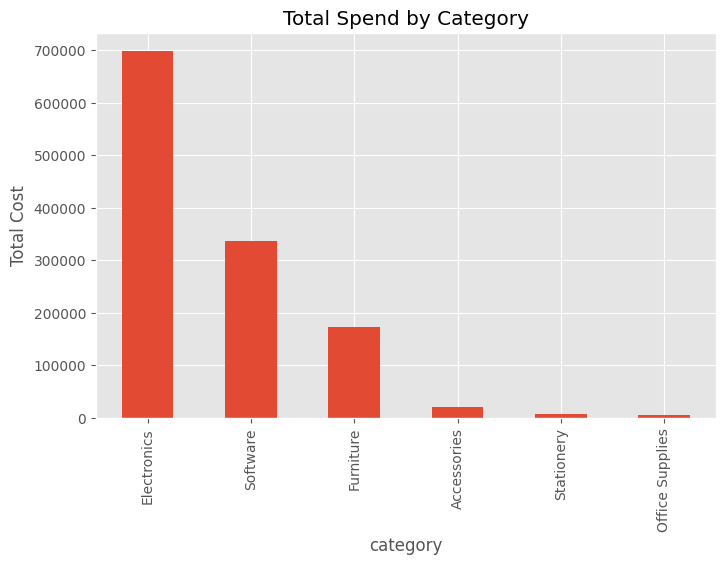

In [31]:
category_spend.plot(kind="bar", figsize=(8,5))
plt.title("Total Spend by Category")
plt.ylabel("Total Cost")
plt.show()


In [32]:
top_items = (
    spend_df.groupby("item_name")["total_cost"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_items


item_name
Laptop                     472284.81
Annual Software License    336018.00
Monitor                    130072.59
Printer                     95447.83
Desk Chair                  91857.82
Whiteboard                  80960.79
Laptop Bag                  20857.24
Stapler                      6328.27
Printer Ink                  5753.89
Notepad                       999.29
Name: total_cost, dtype: float64

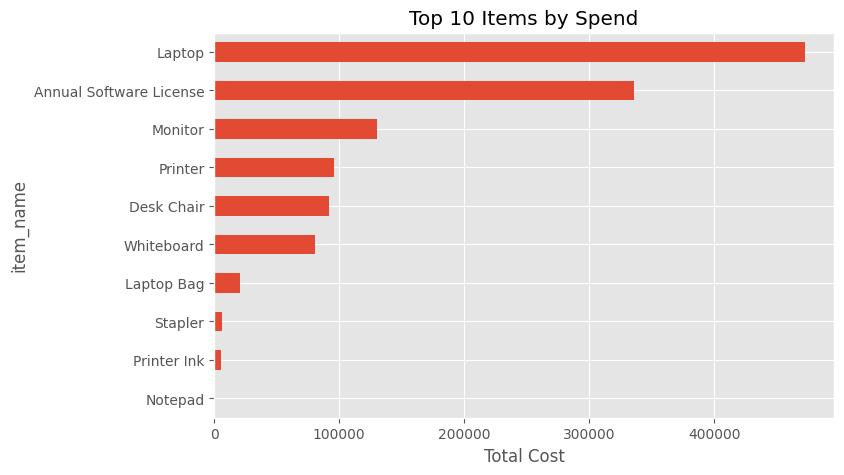

In [33]:
top_items.plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Items by Spend")
plt.xlabel("Total Cost")
plt.gca().invert_yaxis()
plt.show()


In [34]:
supplier_spend = (
    spend_df.groupby("supplier")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

supplier_spend


supplier
TechMart Inc.         328761.73
QuickDeliver Ltd.     285353.59
OfficeSupplies Co.    223580.85
FurniWorks Ltd.       202810.72
CloudSoft Corp.       200073.64
Name: total_cost, dtype: float64

In [35]:
buyer_spend = (
    spend_df.groupby("buyer")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

buyer_spend


buyer
Walter Pena          96418.18
Jasmine Mcgee        94185.73
Dawn Padilla         76908.12
Kelly Joseph         76434.12
Aaron Hopkins        75865.04
Laura White          75235.84
Kayla Hanson         69848.40
Todd James           69219.24
Barry Johnson        68937.27
Melissa Mckee        66169.71
Stephanie Bennett    61853.79
Luis Holland         61082.03
Lisa Parks           58809.01
Cynthia Jenkins      52345.08
Amy Warner           51743.36
Rebecca Bell         51377.32
Jessica Hodges       50654.67
Noah Long            47999.46
Nicole Clay          22017.38
Kevin Adams          13476.78
Name: total_cost, dtype: float64

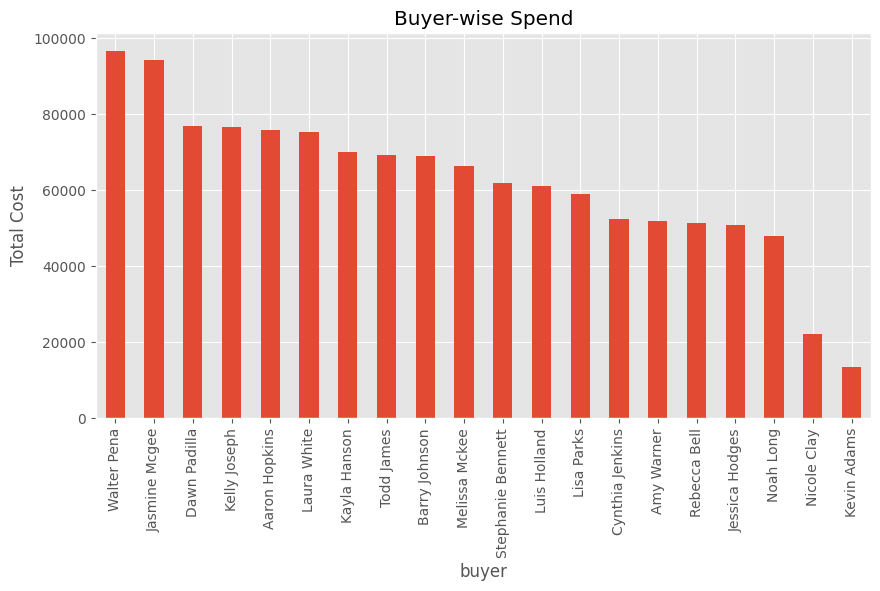

In [36]:
buyer_spend.plot(kind="bar", figsize=(10,5))
plt.title("Buyer-wise Spend")
plt.ylabel("Total Cost")
plt.show()


In [37]:
high_value_txns = spend_df[spend_df["total_cost"] > 5000]
high_value_txns.head()


,transaction_id,item_name,category,quantity,unit_price,total_cost,purchase_date,supplier,buyer,spend_bucket
2,TXN003,Annual Software License,Software,1,5649.34,5649.34,2024-09-10,TechMart Inc.,Kelly Joseph,High Spend
10,TXN011,Annual Software License,Software,1,8183.91,8183.91,2024-01-13,QuickDeliver Ltd.,Aaron Hopkins,High Spend
18,TXN019,Laptop,Electronics,19,815.19,15488.61,2024-10-22,TechMart Inc.,Jasmine Mcgee,High Spend
26,TXN027,Annual Software License,Software,1,5099.86,5099.86,2024-01-10,FurniWorks Ltd.,Stephanie Bennett,High Spend
30,TXN031,Laptop,Electronics,16,980.67,15690.72,2024-05-13,QuickDeliver Ltd.,Luis Holland,High Spend


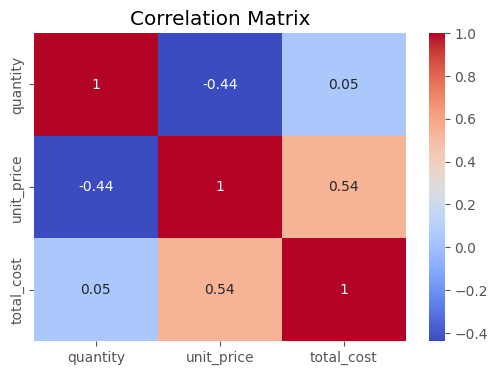

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(
    spend_df[["quantity", "unit_price", "total_cost"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()


In [39]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "abhi123" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "spend_analysis"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "spend_data"   # choose any table name
spend_df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'spend_data' in database 'spend_analysis'.
